/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:27:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model: XGBoost

Feature Weightage:
- diagnoses.figo_stage: 0.2859
- treatments.therapeutic_agents: 0.2654
- diagnoses.tumor_grade: 0.1804
- pathology_details.residual_tumor_measurement: 0.1646
- age_group: 0.1037
----------------------------------------
Model: Random Forest

Feature Weightage:
- treatments.therapeutic_agents: 0.3864
- age_group: 0.2130
- diagnoses.figo_stage: 0.1782
- pathology_details.residual_tumor_measurement: 0.1455
- diagnoses.tumor_grade: 0.0769
----------------------------------------
Model: Logistic Regression

Feature Weightage:
- diagnoses.figo_stage: 0.7631
- age_group: 0.3396
- pathology_details.residual_tumor_measurement: 0.3268
- treatments.therapeutic_agents: 0.1380
- diagnoses.tumor_grade: 0.0340
----------------------------------------
Model: SVM

Feature Weightage: Not available for this model
----------------------------------------


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:27:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


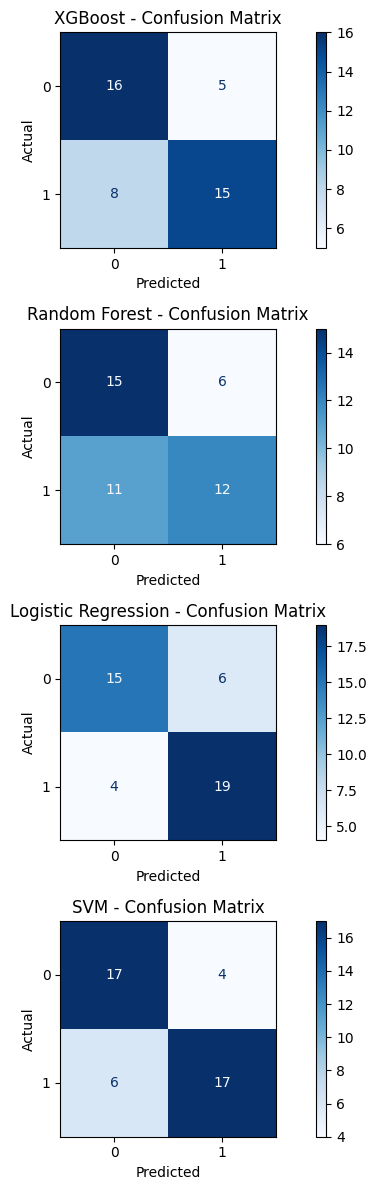

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay
)

# Load dataset
file_path = '/content/final_aibd_dataset.csv'
data = pd.read_csv(file_path)

# Features and target
X = data.drop(columns=['demographic.vital_status'])  # All features except target
y = data['demographic.vital_status']                # Target: survival status
feature_names = X.columns.tolist()

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Initialize models
models = {
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# Train and evaluate models
results = {}
feature_importances = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    results[name] = {'accuracy': accuracy, 'report': report}

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feature_importances[name] = dict(zip(feature_names, importances))
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0]) # For binary classification
        feature_importances[name] = dict(zip(feature_names, importances))
    else:
        feature_importances[name] = "Not available for this model"

# Print results
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    #print(f"Accuracy: {metrics['accuracy']:.2f}")
    #print("Classification Report:")
    #print(metrics['report'])
    if isinstance(feature_importances[model_name], dict):
        print("\nFeature Weightage:")
        for feature, importance in sorted(feature_importances[model_name].items(), key=lambda item: item[1], reverse=True):
            print(f"- {feature}: {importance:.4f}")
    else:
        print(f"\nFeature Weightage: {feature_importances[model_name]}")
    print("-" * 40)

# Fit models, predict, and plot
plt.figure(figsize=(16, 12))
for i, (name, model) in enumerate(models.items(), 1):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    plt.subplot(4, 2, 2*i-1)
    disp.plot(ax=plt.gca(), cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:10:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


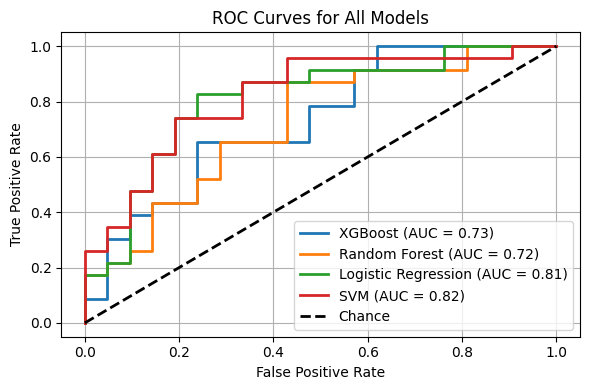

In [ ]:
plt.figure(figsize=(6, 4))

for name, model in models.items():
    # Fit the model (already done above, but safe to repeat for this context)
    model.fit(X_train, y_train)
    # Get predicted probabilities for the positive class
    y_proba = model.predict_proba(X_test)[:, 1]
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    # Plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot the diagonal (chance)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

#Part 2

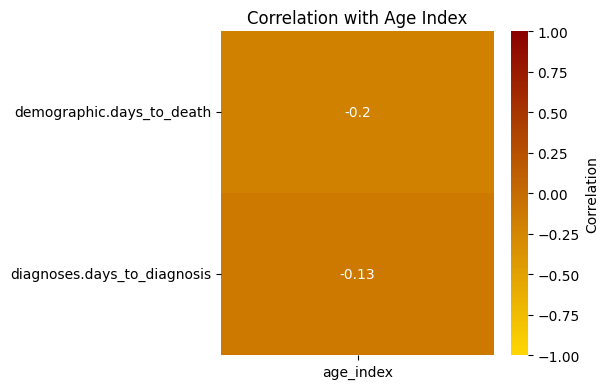

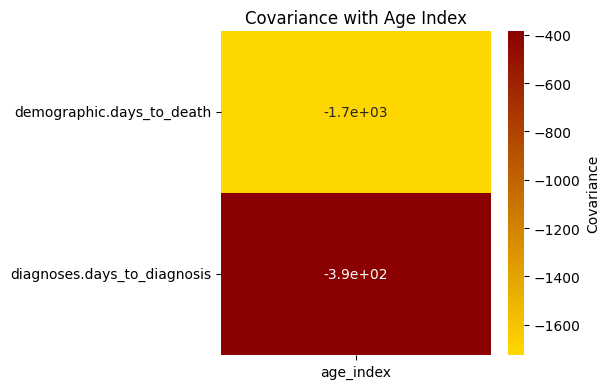

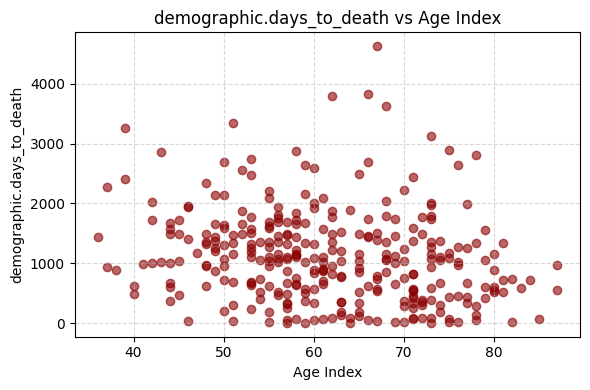

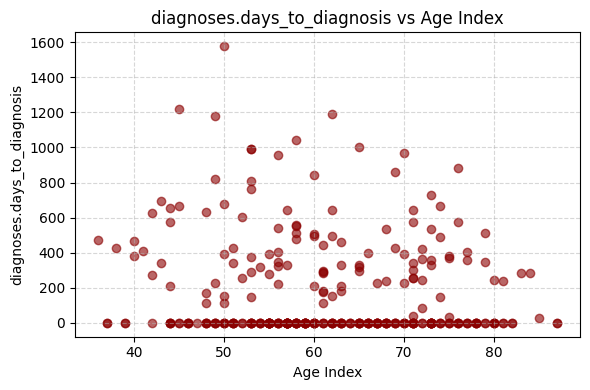

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (update the path as needed)
df = pd.read_csv('/content/dataset_part2_cleaned-2.csv')

# Rename for clarity (if needed)
df = df.rename(columns={'demographic.age_at_index': 'age_index'})

# Drop rows with missing values (optional, depending on your data)
df = df.dropna()

# Get feature columns excluding age_index
features = [col for col in df.columns if col != 'age_index']

# --- CORRELATION HEATMAP ---
corr_matrix = df.corr()

# For gold and dark red, we use a custom colormap
from matplotlib.colors import LinearSegmentedColormap
gold_darkred = LinearSegmentedColormap.from_list('GoldDarkRed', ['#FFD700', '#8B0000'])

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix[['age_index']].loc[features],
    annot=True,
    cmap=gold_darkred,
    vmin=-1, vmax=1,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Correlation with Age Index')
plt.tight_layout()
plt.show()

# --- COVARIANCE HEATMAP ---
cov_matrix = df.cov()

plt.figure(figsize=(6, 4))
sns.heatmap(
    cov_matrix[['age_index']].loc[features],
    annot=True,
    cmap=gold_darkred,
    cbar_kws={'label': 'Covariance'}
)
plt.title('Covariance with Age Index')
plt.tight_layout()
plt.show()

# --- SCATTER PLOTS ---
for feature in features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df['age_index'], df[feature], alpha=0.6, color='#8B0000')
    plt.xlabel('Age Index')
    plt.ylabel(feature)
    plt.title(f'{feature} vs Age Index')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


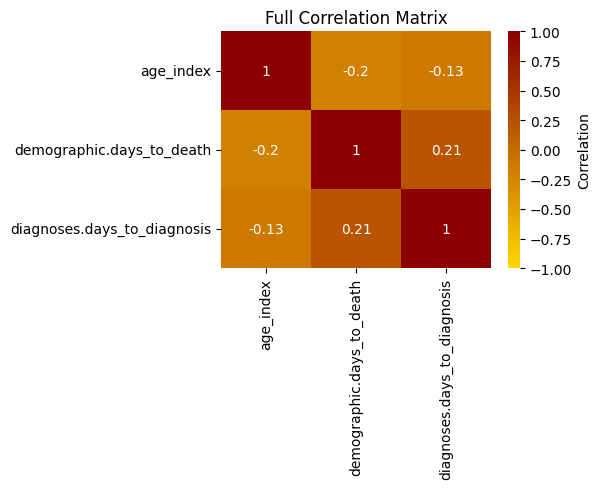

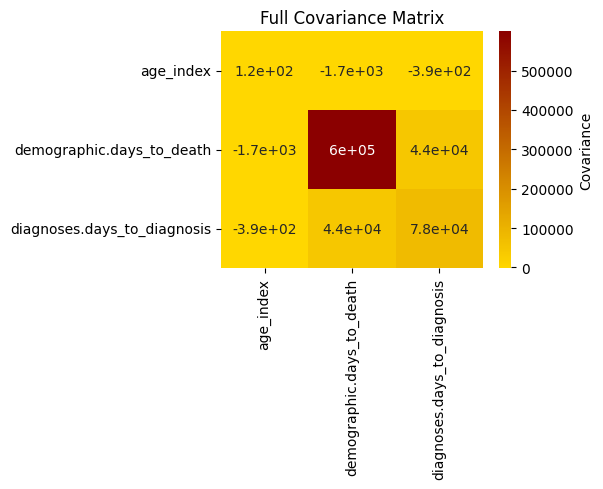

In [ ]:
# --- FULL CORRELATION MATRIX HEATMAP ---
plt.figure(figsize=(6, 5))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap=gold_darkred,
    vmin=-1, vmax=1,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Full Correlation Matrix')
plt.tight_layout()
plt.show()

# --- FULL COVARIANCE MATRIX HEATMAP ---
plt.figure(figsize=(6, 5))
sns.heatmap(
    df.cov(),
    annot=True,
    cmap=gold_darkred,
    cbar_kws={'label': 'Covariance'}
)
plt.title('Full Covariance Matrix')
plt.tight_layout()
plt.show()